# 10 — All-Star Combination (Closing Experiment)

ini menggabungkan **semua fitur** dari notebook 04–09:

| Sumber | Komponen | Alasan |
|---|---|---|
| Notebook 06 | **Multi-station training** | 7× lebih banyak data → mengatasi underfitting di stasiun lemah |
| Notebook 06 | **Latitude & Longitude** | model belajar pola spasial antar lokasi |
| Notebook 07 | **NDVI** dari Google Earth Engine | proxy tutupan hijau |
| Notebook 09 | **Calendar features** (cyclic) | pola weekly + seasonal Jakarta |
| **Baru** | **Multi-seed averaging** (3 seed) | hasil stabil, tidak tergantung lottery init |

Fitur yang **tidak** dipakai (kayaknya bisa dibilang redundan atau rusak):
- Lag features PM2.5/AOD - redundan dengan `lookback=30`
- Rolling mean/std - redundan dengan window LSTM
- Smoothing AOD `center=True` - non-causal, leakage

**Sequence dibuat per-stasiun** lalu di-concat (dari fix bug notebook 06) - tidak ada window yang melintasi batas antar stasiun.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.data_loader import load_all_stations
from src.evaluation import compute_metrics
from src.feature_engineering import add_calendar_features
from src.model import build_lstm, set_seed, train_model
from src.preprocessing import (
    chronological_split, fit_scaler_on_train, transform,
    impute_linear_then_fill, inverse_target, make_sequences,
)

In [ ]:
# Konfigurasi 
FIXED_PARAMS = {'lstm_units': 32, 'dropout_rate': 0.1, 'optimizer': 'adam', 'learning_rate': 1e-3}
EPOCHS = 100
PATIENCE = 20
SEEDS = [42, 123, 2024]  # 3 seed → median + std

# Stasiun yang ikut training & evaluasi
STATIONS_TO_RUN = C.HEALTHY_STATIONS

dfs = load_all_stations(reindex=True)

## 1. dataset gabungan (multi-station, semua fitur all star)

In [3]:
def merge_ndvi(df: pd.DataFrame, station: str) -> pd.DataFrame | None:
    path = C.EXTERNAL_DIR / f'ndvi_{station}.csv'
    if not path.exists():
        return None
    ndvi = pd.read_csv(path, parse_dates=['date']).rename(columns={'date': C.DATE_COL})
    return df.merge(ndvi[[C.DATE_COL, 'NDVI']], on=C.DATE_COL, how='left')


CALENDAR_COLS = ['dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend']
ALL_FEATURES = (
    C.WEATHER_COLS + [C.AOD_COL]
    + ['lat', 'lon']
    + ['NDVI']
    + CALENDAR_COLS
    + [C.TARGET]   # target di posisi terakhir untuk target_idx yang konsisten
)
TARGET_IDX = ALL_FEATURES.index(C.TARGET)
print(f'Total fitur: {len(ALL_FEATURES)} (target di index {TARGET_IDX})')
ALL_FEATURES

Total fitur: 17 (target di index 16)


['temp',
 'dew',
 'humidity',
 'precip',
 'windspeed',
 'AOD',
 'lat',
 'lon',
 'NDVI',
 'dow_sin',
 'dow_cos',
 'month_sin',
 'month_cos',
 'doy_sin',
 'doy_cos',
 'is_weekend',
 'ISPU PM2.5']

In [4]:
def prep_station(df_raw: pd.DataFrame, station: str) -> pd.DataFrame | None:
    """Lengkapi df satu stasiun dengan lat/lon + NDVI + calendar features.
    Return None jika NDVI belum ter-cache untuk stasiun ini.
    """
    df = df_raw.copy()
    df['lat'] = C.STATIONS[station]['lat']
    df['lon'] = C.STATIONS[station]['lon']

    df = merge_ndvi(df, station)
    if df is None or 'NDVI' not in df.columns:
        return None

    df = add_calendar_features(df)
    return df


def build_combined_dataset() -> dict:
    """Imputasi → split → fit scaler pada gabungan train → sequences per-stasiun."""
    train_parts, val_parts, test_meta = [], [], {}
    skipped = []

    for s in STATIONS_TO_RUN:
        df = prep_station(dfs[s], s)
        if df is None:
            skipped.append(s)
            continue

        df = impute_linear_then_fill(df, ALL_FEATURES)
        df = df.dropna(subset=ALL_FEATURES).reset_index(drop=True)

        splits = chronological_split(df)
        train_parts.append(splits.train[ALL_FEATURES])
        val_parts.append(splits.val[ALL_FEATURES])
        test_meta[s] = splits.test[ALL_FEATURES].copy()

    if skipped:
        print(f'⚠️  Skipped (NDVI belum ada): {skipped}')

    # Scaler fit pada gabungan train (no leakage val/test)
    train_concat = pd.concat(train_parts, ignore_index=True)
    scaler = fit_scaler_on_train(train_concat, ALL_FEATURES)

    # Sequences per-stasiun → concat (tidak melintasi batas stasiun)
    def seqs(parts):
        Xs, ys = [], []
        for part in parts:
            if len(part) <= C.LOOKBACK:
                continue
            arr = transform(part, ALL_FEATURES, scaler)
            Xp, yp = make_sequences(arr, TARGET_IDX)
            Xs.append(Xp); ys.append(yp)
        return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)

    X_tr, y_tr = seqs(train_parts)
    X_va, y_va = seqs(val_parts)

    # Test per-stasiun untuk evaluasi terpisah
    test_X, test_y = {}, {}
    for s, df_test in test_meta.items():
        if len(df_test) <= C.LOOKBACK:
            continue
        arr = transform(df_test, ALL_FEATURES, scaler)
        Xs, ys = make_sequences(arr, TARGET_IDX)
        test_X[s] = Xs
        test_y[s] = ys

    return {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val':   X_va, 'y_val':   y_va,
        'test_X':  test_X, 'test_y': test_y,
        'scaler':  scaler, 'feature_cols': ALL_FEATURES, 'target_idx': TARGET_IDX,
        'stations_used': list(test_meta.keys()),
    }

data = build_combined_dataset()
print(f"Train: {data['X_train'].shape}, Val: {data['X_val'].shape}")
print(f"Test stations: {data['stations_used']}")

Train: (5159, 30, 17), Val: (938, 30, 17)
Test stations: ['us_embassy_1', 'us_embassy_2', 'bundaran_hi', 'kelapa_gading', 'jagakarsa', 'lubang_buaya', 'kebun_jeruk']


## 2. Latih dengan multi-seed, evaluasi per-stasiun pada test

In [5]:
n_features = data['X_train'].shape[2]
all_seed_results = {s: [] for s in data['stations_used']}

for seed in SEEDS:
    print(f'\n=== SEED {seed} ===')
    set_seed(seed)
    model = build_lstm(input_shape=(C.LOOKBACK, n_features), **FIXED_PARAMS)
    train_model(
        model,
        data['X_train'], data['y_train'],
        data['X_val'],   data['y_val'],
        epochs=EPOCHS, patience=PATIENCE, verbose=0,
    )

    # Evaluasi per stasiun
    for s in data['stations_used']:
        y_pred = model.predict(data['test_X'][s], verbose=0).flatten()
        y_pred = inverse_target(y_pred, data['scaler'], data['target_idx'], n_features)
        y_true = inverse_target(data['test_y'][s], data['scaler'], data['target_idx'], n_features)
        m = compute_metrics(y_true, y_pred)
        all_seed_results[s].append({'seed': seed, **m})
        print(f"   {s:<18} R²={m['R2']:.4f}  RMSE={m['RMSE']:.2f} µg/m³")


=== SEED 42 ===
   us_embassy_1       R²=0.5188  RMSE=14.63 µg/m³
   us_embassy_2       R²=0.6127  RMSE=15.78 µg/m³
   bundaran_hi        R²=0.3055  RMSE=25.02 µg/m³
   kelapa_gading      R²=0.6631  RMSE=13.36 µg/m³
   jagakarsa          R²=0.4623  RMSE=13.51 µg/m³
   lubang_buaya       R²=0.5537  RMSE=16.45 µg/m³
   kebun_jeruk        R²=0.6141  RMSE=19.17 µg/m³

=== SEED 123 ===
   us_embassy_1       R²=0.6564  RMSE=12.36 µg/m³
   us_embassy_2       R²=0.5877  RMSE=16.28 µg/m³
   bundaran_hi        R²=0.5195  RMSE=20.81 µg/m³
   kelapa_gading      R²=0.7413  RMSE=11.71 µg/m³
   jagakarsa          R²=0.3708  RMSE=14.61 µg/m³
   lubang_buaya       R²=0.4872  RMSE=17.63 µg/m³
   kebun_jeruk        R²=0.6197  RMSE=19.03 µg/m³

=== SEED 2024 ===
   us_embassy_1       R²=0.6079  RMSE=13.20 µg/m³
   us_embassy_2       R²=0.6002  RMSE=16.03 µg/m³
   bundaran_hi        R²=0.6965  RMSE=16.54 µg/m³
   kelapa_gading      R²=0.7710  RMSE=11.02 µg/m³
   jagakarsa          R²=0.3829  RMSE=14.47 µg

## 3. Agregasi multi-seed (median + std)

In [6]:
rows = []
for s, runs in all_seed_results.items():
    df_runs = pd.DataFrame(runs)
    rows.append({
        'station': s,
        'R2_median':  df_runs['R2'].median(),
        'R2_mean':    df_runs['R2'].mean(),
        'R2_std':     df_runs['R2'].std(),
        'R2_min':     df_runs['R2'].min(),
        'R2_max':     df_runs['R2'].max(),
        'RMSE_median': df_runs['RMSE'].median(),
        'MAE_median':  df_runs['MAE'].median(),
        'n_seeds':    len(runs),
    })

df_combined = pd.DataFrame(rows).sort_values('R2_median', ascending=False)
df_combined.to_csv(C.METRICS_DIR / '10_combined_multiseed.csv', index=False)
df_combined.round(4)

,station,R2_median,R2_mean,R2_std,R2_min,R2_max,RMSE_median,MAE_median,n_seeds
3,kelapa_gading,0.7413,0.7251,0.0557,0.6631,0.7710,11.7076,8.0689,3
6,kebun_jeruk,0.6197,0.6429,0.0451,0.6141,0.6948,19.0263,14.4649,3
0,us_embassy_1,0.6079,0.5944,0.0698,0.5188,0.6564,13.2040,9.8648,3
1,us_embassy_2,0.6002,0.6002,0.0125,0.5877,0.6127,16.0287,11.2849,3
5,lubang_buaya,0.5537,0.5321,0.0389,0.4872,0.5553,16.4475,12.2456,3
2,bundaran_hi,0.5195,0.5071,0.1958,0.3055,0.6965,20.8145,14.5684,3
4,jagakarsa,0.3829,0.4053,0.0497,0.3708,0.4623,14.4709,9.8174,3


## 4. Perbandingan dengan skripsi & semua eksperimen sebelumnya

In [7]:
skripsi_r2 = {
    'us_embassy_1':   0.6113,
    'us_embassy_2':   0.6579,
    'bundaran_hi':    0.7748,
    'kelapa_gading':  0.7774,
    'jagakarsa':      0.6329,
    'lubang_buaya':   0.5121,
    'kebun_jeruk':    0.7155,
}

# Cari best dari setiap eksperimen sebelumnya per stasiun
def safe_load(name, key='R2'):
    try:
        return pd.read_csv(C.METRICS_DIR / name)
    except FileNotFoundError:
        return None

# Best per stasiun dari notebook 03-09
best_prev = {}
for s in df_combined['station']:
    candidates = []
    grid = safe_load('03_grid_best_summary.csv')
    if grid is not None:
        v = grid[grid['station'] == s]['R2'].values
        if len(v): candidates.append(('03_grid', float(v[0])))

    opt = safe_load('04_optuna_summary.csv')
    if opt is not None:
        v = opt[opt['station'] == s]['R2'].values
        if len(v) and v[0] > -1: candidates.append(('04_optuna', float(v[0])))

    ll = safe_load('06_lat_long_comparison.csv')
    if ll is not None:
        for variant in ['no_coords', 'with_coords']:
            v = ll[(ll['station'] == s) & (ll['variant'] == variant)]['R2'].values
            if len(v): candidates.append((f'06_{variant}', float(v[0])))

    nd = safe_load('07_ndvi_comparison.csv')
    if nd is not None:
        v = nd[nd['station'] == s]['R2_ndvi'].values
        if len(v) and v[0] > -1: candidates.append(('07_ndvi', float(v[0])))

    if candidates:
        best_prev[s] = max(candidates, key=lambda x: x[1])

df_compare = df_combined[['station', 'R2_median', 'R2_std']].copy()
df_compare['R2_skripsi'] = df_compare['station'].map(skripsi_r2)
df_compare['best_prev_exp'] = df_compare['station'].map(lambda s: best_prev.get(s, ('-', np.nan))[0])
df_compare['R2_best_prev']  = df_compare['station'].map(lambda s: best_prev.get(s, ('-', np.nan))[1])
df_compare['vs_skripsi']    = df_compare['R2_median'] - df_compare['R2_skripsi']
df_compare['vs_best_prev']  = df_compare['R2_median'] - df_compare['R2_best_prev']

df_compare.to_csv(C.METRICS_DIR / '10_final_showdown.csv', index=False)
df_compare.round(4)

,station,R2_median,R2_std,R2_skripsi,best_prev_exp,R2_best_prev,vs_skripsi,vs_best_prev
3,kelapa_gading,0.7413,0.0557,0.7774,07_ndvi,0.7741,-0.0361,-0.0328
6,kebun_jeruk,0.6197,0.0451,0.7155,06_no_coords,0.7134,-0.0958,-0.0937
0,us_embassy_1,0.6079,0.0698,0.6113,06_with_coords,0.6448,-0.0034,-0.0369
1,us_embassy_2,0.6002,0.0125,0.6579,06_with_coords,0.6286,-0.0577,-0.0284
5,lubang_buaya,0.5537,0.0389,0.5121,06_no_coords,0.4676,0.0416,0.0861
2,bundaran_hi,0.5195,0.1958,0.7748,06_with_coords,0.7580,-0.2553,-0.2385
4,jagakarsa,0.3829,0.0497,0.6329,06_with_coords,0.5409,-0.2500,-0.1581


## 5. Plot final showdown

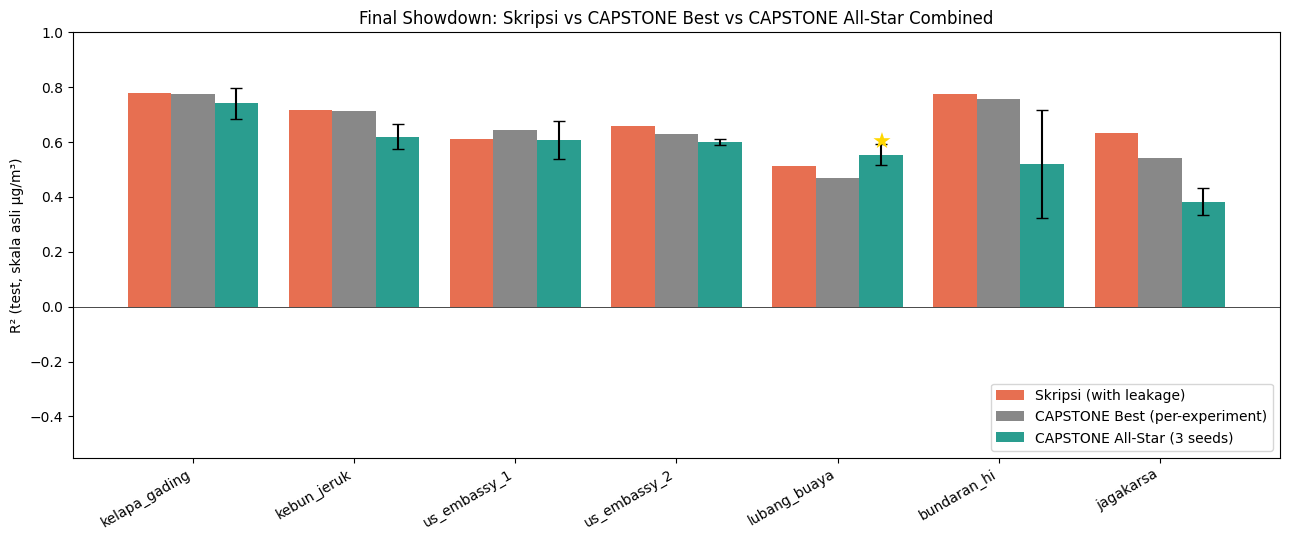


★ All-Star melampaui skripsi di 1/7 stasiun


In [8]:
R2_FLOOR = -0.5
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(df_compare))
w = 0.27

skripsi_vals = df_compare['R2_skripsi'].clip(lower=R2_FLOOR)
prev_vals    = df_compare['R2_best_prev'].clip(lower=R2_FLOOR)
comb_vals    = df_compare['R2_median'].clip(lower=R2_FLOOR)

ax.bar(x - w, skripsi_vals, w, label='Skripsi (with leakage)', color='#e76f51')
ax.bar(x,     prev_vals,    w, label='CAPSTONE Best (per-experiment)', color='#888')
# Kombinasi all-star dengan error bar = std seed
ax.bar(x + w, comb_vals,    w,
       yerr=df_compare['R2_std'].fillna(0).clip(upper=0.3),
       capsize=4,
       label=f'CAPSTONE All-Star ({len(SEEDS)} seeds)', color='#2a9d8f')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(df_compare['station'], rotation=30, ha='right')
ax.set_ylim(R2_FLOOR - 0.05, 1.0)
ax.set_ylabel('R² (test, skala asli µg/m³)')
ax.set_title('Final Showdown: Skripsi vs CAPSTONE Best vs CAPSTONE All-Star Combined')
ax.legend(loc='lower right')

# Annotate yang lewat skripsi
for i, (med, sk) in enumerate(zip(df_compare['R2_median'], df_compare['R2_skripsi'])):
    if med > sk:
        ax.text(i + w, max(med, R2_FLOOR) + 0.02, '★',
                ha='center', fontsize=16, color='gold', fontweight='bold')

plt.tight_layout()
plt.savefig(C.FIG_DIR / '10_final_showdown.png', dpi=120)
plt.show()

n_beat = (df_compare['R2_median'] > df_compare['R2_skripsi']).sum()
print(f'\n★ All-Star melampaui skripsi di {n_beat}/{len(df_compare)} stasiun')